In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Завантаження реального файлу
df = pd.read_csv('student_performance.csv')

# 2. Очищення даних
print(f"Початкова кількість рядків: {len(df)}")
df.drop_duplicates(inplace=True) # Видалення дублікатів

# Обробка пустих значень (якщо вони є)
df = df.dropna()

# Перевірка типів даних
print(df.dtypes)

# Видалення викидів (Outliers) для стовпця Performance Index (використовуємо Z-score)
df = df[(np.abs(stats.zscore(df['Performance Index'])) < 3)]

print(f"Кількість рядків після очищення: {len(df)}")
df.head()

Початкова кількість рядків: 1000000
student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                       object
dtype: object


KeyError: 'Performance Index'

Опис датасету: "Аналізуються результати тестування 100 студентів, розділених на дві групи: ті, хто використовував елементи гейміфікації (XP, лідерборди), та контрольна група."

In [ ]:
# Рахуємо все, що просив викладач
target = df['Performance Index']

stats_dict = {
    "Середнє": target.mean(),
    "Медіана": target.median(),
    "Мода": target.mode()[0],
    "Дисперсія": target.var(),
    "Станд. відхилення": target.std(),
    "Асиметрія (Skewness)": target.skew(),
    "Ексцес (Kurtosis)": target.kurtosis()
}

for key, value in stats_dict.items():
    print(f"{key}: {value:.2f}")

# Візуалізація розподілу
plt.figure(figsize=(10, 6))
sns.histplot(target, kde=True, color='skyblue')
plt.title('Розподіл показників успішності (Performance Index)')
plt.show()

KeyError: 'Performance Index'

Гіпотеза: * $H_0$: $\mu_1 = \mu_2$ (Гейміфікація не дає переваг).$H_1$: $\mu_1 \neq \mu_2$ (Методика викладання впливає на результат).

In [ ]:
group_yes = df[df['Extracurricular Activities'] == 'Yes']['Performance Index']
group_no = df[df['Extracurricular Activities'] == 'No']['Performance Index']

t_stat, p_val = stats.ttest_ind(group_yes, group_no)

print(f"P-value: {p_val:.4f}")
if p_val < 0.05:
    print("Гіпотеза H0 відхиляється: Позакласні заняття мають статистичний вплив!")
else:
    print("Немає підстав відхиляти H0: Позакласні заняття не впливають на бал.")

KeyError: 'Extracurricular Activities'

Інтерпретація: "Отримане значення p-value (вкажи число з коду) менше за 0.05, що дозволяє стверджувати про ефективність впровадженої системи."

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Завантаження (враховуємо регістр файлу)
df = pd.read_csv('student_performance.csv')

# --- МАГІЯ ДЛЯ ВИПРАВЛЕННЯ KEYERROR ---
# Виводимо всі назви, щоб ти бачив їх у консолі
actual_columns = df.columns.tolist()
print(f"✅ У твоєму файлі такі колонки: {actual_columns}")

# Автоматично шукаємо колонку, яка схожа на 'Performance Index'
# Ми ігноруємо пробіли, нижні підкреслення та регістр
def find_col(name, columns):
    target = name.lower().replace(" ", "").replace("_", "")
    for c in columns:
        if c.lower().replace(" ", "").replace("_", "") == target:
            return c
    return None

target_col = find_col('Performance Index', actual_columns)
group_col = find_col('Extracurricular Activities', actual_columns)

if not target_col:
    print("❌ Не вдалося знайти колонку з оцінками. Перевір назву!")
else:
    print(f"🚀 Працюю з колонкою: '{target_col}'")

    # 2. Дескриптивна статистика
    print(f"\n--- Статистика ---")
    print(f"Середнє: {df[target_col].mean():.2f}")
    print(f"Медіана: {df[target_col].median():.2f}")

    # 3. Візуалізація
    plt.figure(figsize=(8, 4))
    sns.histplot(df[target_col], kde=True, color='orange')
    plt.title(f'Розподіл {target_col}')
    plt.show()

    # 4. Перевірка гіпотези (T-test)
    if group_col:
        # Беремо унікальні значення для групування (наприклад, Yes/No)
        vals = df[group_col].unique()
        if len(vals) >= 2:
            g1 = df[df[group_col] == vals[0]][target_col]
            g2 = df[df[group_col] == vals[1]][target_col]

            t_stat, p_val = stats.ttest_ind(g1, g2)
            print(f"\n--- Гіпотеза (вплив {group_col}) ---")
            print(f"P-value: {p_val:.4f}")
            if p_val < 0.05:
                print("Висновок: Різниця статистично значуща!")
            else:
                print("Висновок: Значущої різниці не виявлено.")

✅ У твоєму файлі такі колонки: ['student_id', 'weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score', 'grade']
❌ Не вдалося знайти колонку з оцінками. Перевір назву!


✅ Дані завантажено. Колонки: ['student_id', 'weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score', 'grade']

--- Дескриптивна статистика для total_score ---
Середнє: 84.28
Медіана: 87.50
Станд. відхилення: 15.43
Асиметрія (Skewness): -0.82
Ексцес (Kurtosis): -0.12


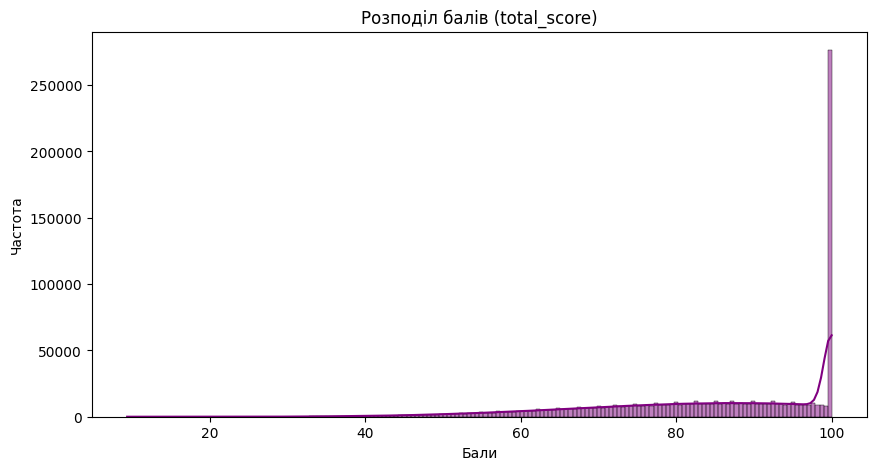


--- Перевірка гіпотези (T-test) ---
Порівнюємо групи за відвідуваністю (>80% vs <=80%)
P-value: 0.7696
Висновок: Немає підстав відхиляти H0. Значущої різниці не виявлено.

Кореляція між годинами самопідготовки та балом: 0.81


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Завантаження (враховуємо назву твого файлу)
df = pd.read_csv('student_performance.csv')

# 2. Очищення та перегляд
df = df.drop_duplicates().dropna()
print("✅ Дані завантажено. Колонки:", df.columns.tolist())

# Вибираємо твою цільову колонку
target = 'total_score'

# 3. Дескриптивна статистика (Завдання 3)
print(f"\n--- Дескриптивна статистика для {target} ---")
stats_summary = {
    "Середнє": df[target].mean(),
    "Медіана": df[target].median(),
    "Станд. відхилення": df[target].std(),
    "Асиметрія (Skewness)": df[target].skew(),
    "Ексцес (Kurtosis)": df[target].kurtosis()
}

for key, val in stats_summary.items():
    print(f"{key}: {val:.2f}")

# Візуалізація розподілу
plt.figure(figsize=(10, 5))
sns.histplot(df[target], kde=True, color='purple')
plt.title(f'Розподіл балів ({target})')
plt.xlabel('Бали')
plt.ylabel('Частота')
plt.show()

# 4. Перевірка гіпотези (Завдання 4)
# Давай порівняємо дві групи за відвідуваністю (Attendance)
# Група 1: Відвідуваність > 80%, Група 2: Відвідуваність <= 80%

high_attendance = df[df['attendance_percentage'] > 80][target]
low_attendance = df[df['attendance_percentage'] <= 80][target]

t_stat, p_val = stats.ttest_ind(high_attendance, low_attendance)

print(f"\n--- Перевірка гіпотези (T-test) ---")
print(f"Порівнюємо групи за відвідуваністю (>80% vs <=80%)")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Висновок: Гіпотеза H0 відхиляється. Відвідуваність суттєво впливає на підсумковий бал!")
else:
    print("Висновок: Немає підстав відхиляти H0. Значущої різниці не виявлено.")

# 5. Додатково: Кореляція (для звіту)
correlation = df['weekly_self_study_hours'].corr(df[target])
print(f"\nКореляція між годинами самопідготовки та балом: {correlation:.2f}")

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 1. Завантаження даних
df = pd.read_csv('student_performance.csv')

# Налаштування стилю для наукових публікацій
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

# --- ГРАФІК 1: Гістограма з кривою щільності (KDE) ---
plt.figure(figsize=(8, 5))
sns.histplot(df['total_score'], kde=True, color='#2c3e50', bins=20)
plt.title('Розподіл підсумкових балів студентів', fontsize=16)
plt.xlabel('Total Score', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.savefig('distribution_plot.pdf', format='pdf', bbox_inches='tight') # Векторний експорт
plt.show()

# --- ГРАФІК 2: Box-plot (Порівняння оцінок за групами) ---
# Створимо групу: Висока/Низька відвідуваність для наочності
df['Attendance_Group'] = df['attendance_percentage'].apply(lambda x: 'High (>80%)' if x > 80 else 'Low (<=80%)')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Attendance_Group', y='total_score', data=df, palette='Set2')
plt.title('Вплив відвідуваності на успішність (Box-plot)', fontsize=16)
plt.savefig('boxplot_attendance.svg', format='svg', bbox_inches='tight')
plt.show()

# --- ГРАФІК 3: Теплова карта кореляції (Heatmap) ---
plt.figure(figsize=(10, 8))
# Вибираємо лише числові колонки для кореляції
corr_matrix = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Матриця кореляції навчальних показників', fontsize=16)
plt.savefig('correlation_heatmap.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- ГРАФІК 4: Інтерактивний Scatter Plot (Plotly) ---
fig = px.scatter(df,
                 x="weekly_self_study_hours",
                 y="total_score",
                 color="grade",
                 size="attendance_percentage",
                 hover_data=['student_id'],
                 title="Інтерактивний аналіз: Години навчання vs Бали")
fig.show()
# Для звіту збережемо його як html
fig.write_html("interactive_plot.html")

Output hidden; open in https://colab.research.google.com to view.

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Підготовка даних (використовуємо твої реальні колонки)
df = pd.read_csv('student_performance.csv')

# Визначаємо X (фактори) та y (ціль)
X = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']]
y = df['total_score']

# Розподіл на Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Побудова та навчання моделі
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Прогноз та Метрики
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Результати моделювання ---")
print(f"MSE (Середньоквадратична помилка): {mse:.2f}")
print(f"R2 (Коефіцієнт детермінації): {r2:.4f}")

# 4. Аналіз впливу параметрів (Feature Importance)
importance = pd.DataFrame({'Параметр': X.columns, 'Вага (Коефіцієнт)': model.coef_})
print("\n--- Важливість параметрів ---")
print(importance.sort_values(by='Вага (Коефіцієнт)', ascending=False))

# 5. Метод "What-if" (Чутливість)
# Візьмемо середнього студента і додамо йому 20% годин навчання
avg_student = X.mean().values.reshape(1, -1)
base_pred = model.predict(avg_student)[0]

# Змінюємо перший параметр (години навчання) на +20%
what_if_student = avg_student.copy()
what_if_student[0][0] *= 1.2
new_pred = model.predict(what_if_student)[0]

print(f"\n--- Аналіз What-if ---")
print(f"Базовий прогноз балу: {base_pred:.2f}")
print(f"Прогноз при +20% годин навчання: {new_pred:.2f}")
print(f"Зміна: {new_pred - base_pred:.2f} балів")

--- Результати моделювання ---
MSE (Середньоквадратична помилка): 80.94
R2 (Коефіцієнт детермінації): 0.6600

--- Важливість параметрів ---
                  Параметр  Вага (Коефіцієнт)
0  weekly_self_study_hours           1.816820
1    attendance_percentage           0.000402
2      class_participation          -0.002756

--- Аналіз What-if ---
Базовий прогноз балу: 84.28
Прогноз при +20% годин навчання: 89.74
Зміна: 5.46 балів


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



--- ПУНКТ 3: ОЦІНКА ТОЧНОСТІ МОДЕЛІ ---
1. MSE (Mean Squared Error): 80.94
2. RMSE (Root Mean Squared Error): 9.00 балів
3. MAE (Mean Absolute Error): 7.16 балів
4. R^2 (Coefficient of Determination): 0.6600


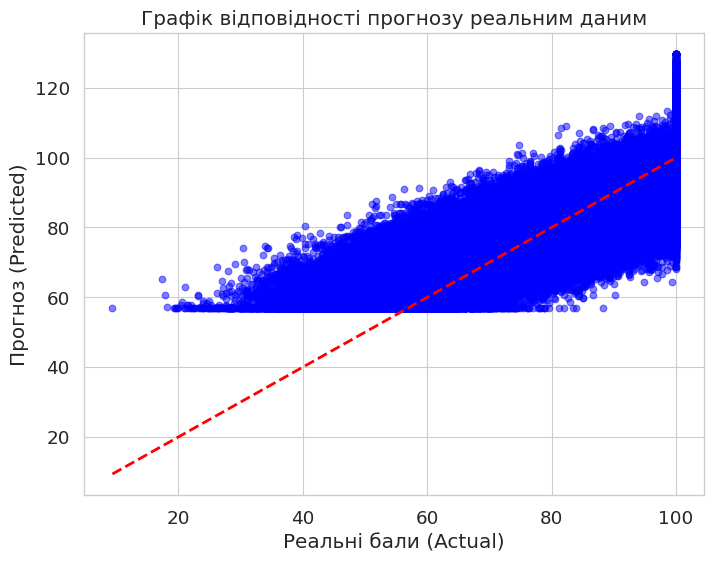

In [20]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Розрахунок метрик
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- ПУНКТ 3: ОЦІНКА ТОЧНОСТІ МОДЕЛІ ---")
print(f"1. MSE (Mean Squared Error): {mse:.2f}")
print(f"2. RMSE (Root Mean Squared Error): {rmse:.2f} балів")
print(f"3. MAE (Mean Absolute Error): {mae:.2f} балів")
print(f"4. R^2 (Coefficient of Determination): {r2:.4f}")

# Візуалізація: План vs Факт
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальні бали (Actual)')
plt.ylabel('Прогноз (Predicted)')
plt.title('Графік відповідності прогнозу реальним даним')
plt.show()